In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df2 = pd.read_csv("data/S07-hw-dataset-02.csv")
df3 = pd.read_csv("data/S07-hw-dataset-03.csv")
df4 = pd.read_csv("data/S07-hw-dataset-04.csv")

In [3]:
display(df2.head())
display(df2.info())
display(df2.describe())

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


None

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [4]:
display(df3.head())
display(df3.info())
display(df3.describe())

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


None

,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [5]:
display(df4.head())
display(df4.info())
display(df4.describe())

,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,B,X,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,F,V,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,A,W,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,B,X,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,C,Y,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-null   float64
 20  n18    

None

,sample_id,n01,n02,n03,n04,n05,n06,n07,n08,n09,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
count,10000.00000,9826.000000,9811.000000,9801.000000,9808.000000,9799.000000,9817.000000,9796.000000,9806.000000,9805.000000,...,9785.000000,9804.000000,9829.000000,9793.000000,9815.000000,9776.000000,9803.000000,9789.000000,9798.000000,9805.000000
mean,4999.50000,17.348435,-2.057620,7.908302,14.269157,0.900590,5.832787,-0.840875,-4.888128,3.184200,...,-12.716502,-0.506241,8.360226,0.026943,0.039297,-0.037155,0.028512,-0.030738,-0.018685,-0.030254
std,2886.89568,22.578551,19.043410,25.637807,18.815319,20.981294,13.221646,26.583849,15.466271,32.208740,...,37.290305,14.336833,17.754646,26.121335,3.009995,3.020813,3.028106,3.000090,3.014209,3.014573
min,0.00000,-22.437090,-37.546998,-38.136412,-23.374316,-45.914070,-20.650038,-60.297304,-44.464550,-70.904880,...,-89.640783,-35.102360,-25.014050,-49.423300,-11.225848,-14.446922,-10.840777,-11.679259,-11.437909,-11.491223
25%,2499.75000,-3.975438,-14.200552,-8.591513,-1.223379,-5.086756,-4.532057,-13.554720,-17.352641,-11.460490,...,-41.284671,-11.563652,-2.123576,-19.425213,-1.973213,-2.082235,-2.007628,-2.074500,-2.051778,-2.074396
50%,4999.50000,22.042807,-6.532183,0.350400,10.069142,2.413111,7.391953,-2.429024,-7.095546,13.258691,...,-1.145681,2.491416,6.691365,-8.464171,0.037806,-0.033336,0.031588,-0.043127,-0.015441,-0.015903
75%,7499.25000,37.535647,2.092197,30.725630,29.807101,18.398883,13.033076,16.095731,3.909111,20.188426,...,18.916379,11.903004,14.939690,16.861978,2.048648,2.019027,2.056870,1.980217,2.013964,2.031215
max,9999.00000,65.446912,43.326647,60.185729,65.094588,42.527554,39.933274,48.591236,31.335431,64.696045,...,49.157087,22.452135,46.892903,61.540902,11.002135,11.394631,11.936846,10.663960,10.665988,13.755203


In [6]:
has_na = 0
for i in df2.columns:
    if df2[i].isna().mean() != 0:
        print(i, df2[i].isna().mean())
        has_na = 1
if has_na == 0:
    print('Нет пропусков')

print()

print(df2.dtypes)

Нет пропусков

sample_id      int64
x1           float64
x2           float64
z_noise      float64
dtype: object


In [7]:
has_na = 0
for i in df3.columns:
    if df3[i].isna().mean() != 0:
        print(i, df3[i].isna().mean())
        has_na = 1
if has_na == 0:
    print('Нет пропусков')

print()

print(df3.dtypes)

Нет пропусков

sample_id      int64
x1           float64
x2           float64
f_corr       float64
f_noise      float64
dtype: object


In [8]:
has_na = 0
for i in df4.columns:
    if df4[i].isna().mean() != 0:
        print(i, df4[i].isna().mean())
        has_na = 1
if has_na == 0:
    print('Нет пропусков')

print()

print(df4.dtypes)

n01 0.0174
n02 0.0189
n03 0.0199
n04 0.0192
n05 0.0201
n06 0.0183
n07 0.0204
n08 0.0194
n09 0.0195
n10 0.0189
n11 0.0204
n12 0.0202
n13 0.0197
n14 0.0198
n15 0.0186
n16 0.0191
n17 0.0212
n18 0.0212
n19 0.0187
n20 0.0203
n21 0.0215
n22 0.0196
n23 0.0171
n24 0.0207
n25 0.0185
n26 0.0224
n27 0.0197
n28 0.0211
n29 0.0202
n30 0.0195

sample_id      int64
cat_a         object
cat_b         object
n01          float64
n02          float64
n03          float64
n04          float64
n05          float64
n06          float64
n07          float64
n08          float64
n09          float64
n10          float64
n11          float64
n12          float64
n13          float64
n14          float64
n15          float64
n16          float64
n17          float64
n18          float64
n19          float64
n20          float64
n21          float64
n22          float64
n23          float64
n24          float64
n25          float64
n26          float64
n27          float64
n28          float64
n29          float

In [9]:
sample_id2 = df2["sample_id"]
sample_id3 = df3["sample_id"]
sample_id4 = df4["sample_id"]

X2 = df2.drop("sample_id", axis=1)
X3 = df3.drop("sample_id", axis=1)
X4 = df4.drop("sample_id", axis=1)
# display(X2.head())
# display(X3.head())
# display(X4.head())

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), make_column_selector(dtype_include='object'))
    ],
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

X2_scaled = preprocessor.fit_transform(X2)
X3_scaled = preprocessor.fit_transform(X3)
X4_scaled = preprocessor.fit_transform(X4)

display(X4_scaled)

,n01,n02,n03,n04,n05,n06,n07,n08,n09,n10,...,cat_a_C,cat_a_D,cat_a_E,cat_a_F,cat_b_U,cat_b_V,cat_b_W,cat_b_X,cat_b_Y,cat_b_Z
0,-0.990877,-1.190239,-0.621008,-7.243854e-01,1.319188,-0.788331,-1.593639e+00,-0.802151,0.141391,0.333849,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.517153,0.000000,-0.093521,1.987687e+00,-0.429893,1.714940,-1.265935e-17,-0.868612,1.192580,0.570577,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.990579,-0.030102,0.787359,-6.840663e-01,-0.321513,-1.689485,1.255727e-01,0.691290,-0.468964,-2.023222,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.892578,-1.219726,-0.683933,-1.213653e+00,1.033812,-1.325143,-1.631388e+00,-0.142026,0.097479,0.152551,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.285254,-0.351748,1.604714,2.107397e-02,-1.951783,0.376832,1.559425e+00,-0.165343,0.375706,-0.118724,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.352431,-0.382244,1.555844,1.203455e-01,-2.052640,0.150174,1.716809e+00,0.219369,0.440455,-0.099100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9996,1.559697,-0.157056,-0.272430,2.092837e+00,-0.739151,2.358822,1.101739e+00,-1.244794,1.740950,0.978867,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
9997,0.722729,2.083271,-1.333135,-6.054389e-01,0.911722,0.581670,-3.581513e-01,2.032176,-1.936198,1.219859,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9998,-1.430809,-0.524460,1.616588,-4.077945e-02,-1.966035,0.076081,1.441116e+00,-0.334504,0.463109,-0.312635,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [11]:
pca_model2 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_feat2 = pca_model2.fit_transform(X2_scaled)
pca_model3 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_feat3 = pca_model3.fit_transform(X3_scaled)
pca_model4 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_feat4 = pca_model4.fit_transform(X4_scaled)

print(pca_model2.explained_variance_ratio_, sum(pca_model2.explained_variance_ratio_))
print(pca_model3.explained_variance_ratio_, sum(pca_model3.explained_variance_ratio_))
print(pca_model4.explained_variance_ratio_, sum(pca_model4.explained_variance_ratio_))


[0.42544068 0.33365792 0.2409014 ] 1.0
[0.44160951 0.27761703 0.24989181] 0.9691183407886592
[0.26688557 0.22308333 0.14288659 0.08501538 0.03416585 0.03206473
 0.03182466 0.03166629 0.03151795 0.03125624 0.03057977 0.01462325] 0.9555695956329192


In [12]:
kmeans_ks = list(range(2, 21))

dbscan_eps = [0.5, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 4, 4.5, 5]
dbscan_min_samples = [3,5,10]

agg_ks = list(range(2, 21))
agg_linkages = ['ward', 'complete', 'average']

In [13]:
def safe_cluster_metrics(X, labels):
    """Считает метрики; возвращает None, если метрика неприменима."""
    unique = np.unique(labels)
    # Нужно минимум 2 кластера
    if len(unique) < 2:
        return None

    # Нельзя, чтобы все точки были в одном кластере
    if len(unique) == 1:
        return None

    # silhouette требует, чтобы все кластеры имели >1 точки (часто, но не всегда)
    # В sklearn silhouette_score может падать, если какой-то кластер пуст/особый.
    try:
        sil = float(silhouette_score(X, labels))
    except Exception:
        sil = None

    try:
        db = float(davies_bouldin_score(X, labels))
    except Exception:
        db = None

    try:
        ch = float(calinski_harabasz_score(X, labels))
    except Exception:
        ch = None

    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

def pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE):
    """PCA(2D) именно для визуализации."""
    p = PCA(n_components=2, random_state=random_state)
    return p.fit_transform(X_scaled)

def plot_2d_embedding(emb2d, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.grid(True, alpha=0.2)
    plt.savefig(f"artifacts/figures/{title}")
    plt.show()

def summarize_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))

In [14]:
def eval_kmeans_grid(X_feat, ks, random_state = 42):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=random_state, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

In [15]:
kmeans_results2 = eval_kmeans_grid(X_feat2, kmeans_ks)


In [16]:
kmeans_results3 = eval_kmeans_grid(X_feat3, kmeans_ks)

In [17]:
kmeans_results4 = eval_kmeans_grid(X_feat4, kmeans_ks)

In [18]:
def sil_inert_vs_k_grid(kmeans_results, title_sil: str, title_dav: str, title_cal: str):
    ks = [r["params"]["k"] for r in kmeans_results]
    sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results]
    dav = [r["metrics"]["davies_bouldin"] if r["metrics"] else None for r in kmeans_results]
    cal = [r["metrics"]["calinski_harabasz"] if r["metrics"] else None for r in kmeans_results]

    plt.figure(figsize=(7, 4))
    plt.plot(ks, sil, marker="o")
    plt.title(title_sil)
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True, alpha=0.25)
    plt.savefig(f'artifacts/figures/{title_sil}')
    plt.show()

    # Инерция (elbow) – как эвристика
    # inertia = [r["inertia"] for r in kmeans_results]
    # plt.figure(figsize=(7, 4))
    # plt.plot(ks, inertia, marker="o")
    # plt.title(title_inert)
    # plt.xlabel("k")
    # plt.ylabel("inertia")
    # plt.grid(True, alpha=0.25)
    # plt.savefig(f'artifacts/figures/{title_inert}')
    # plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(ks, dav, marker="o")
    plt.title(title_dav)
    plt.xlabel("k")
    plt.ylabel("davies_bouldin")
    plt.grid(True, alpha=0.25)
    plt.savefig(f'artifacts/figures/{title_dav}')
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(ks, cal, marker="o")
    plt.title(title_cal)
    plt.xlabel("k")
    plt.ylabel("calinski_harabasz")
    plt.grid(True, alpha=0.25)
    plt.savefig(f'artifacts/figures/{title_cal}')
    plt.show()

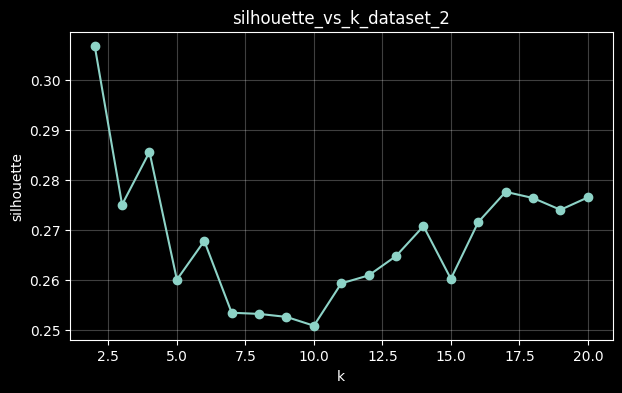

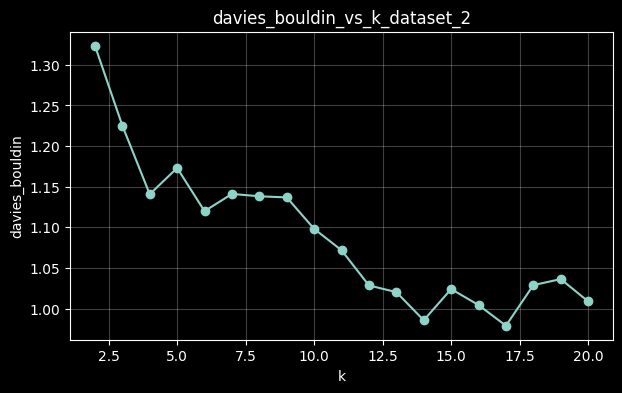

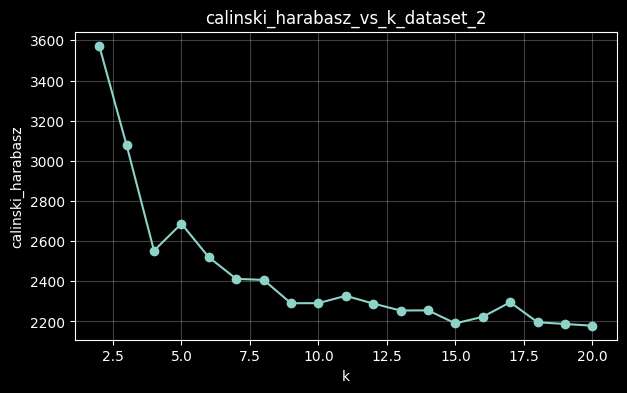

In [19]:
sil_inert_vs_k_grid(kmeans_results2, "silhouette_vs_k_dataset_2", "davies_bouldin_vs_k_dataset_2", "calinski_harabasz_vs_k_dataset_2")

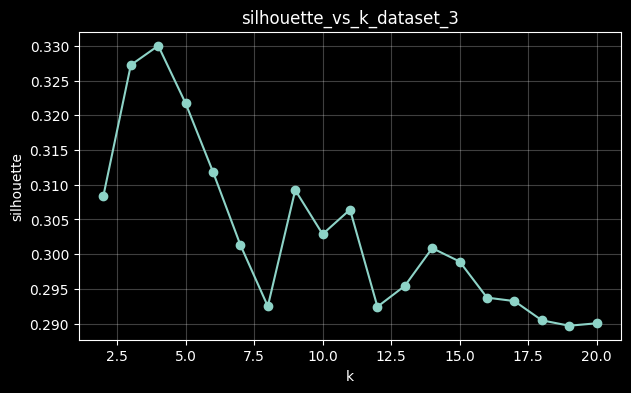

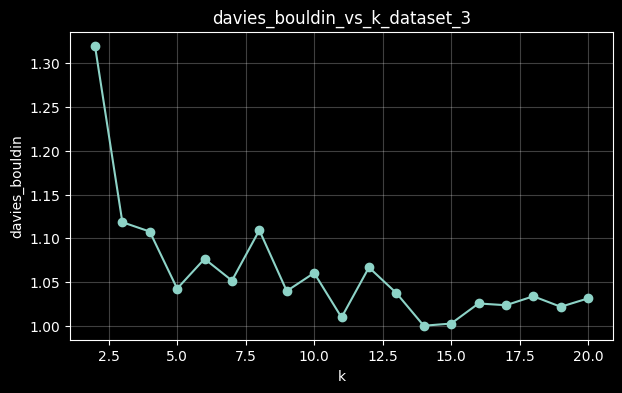

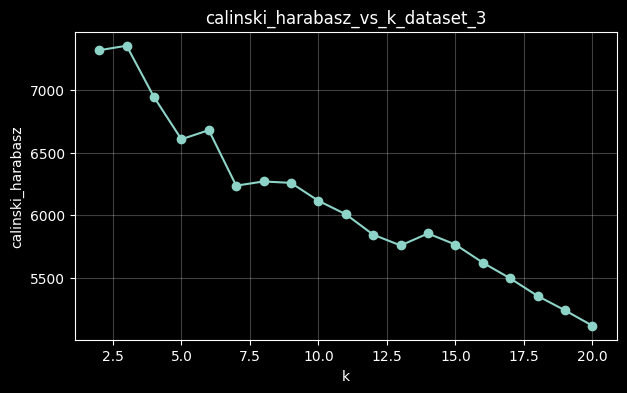

In [20]:
sil_inert_vs_k_grid(kmeans_results3, "silhouette_vs_k_dataset_3", "davies_bouldin_vs_k_dataset_3", "calinski_harabasz_vs_k_dataset_3")

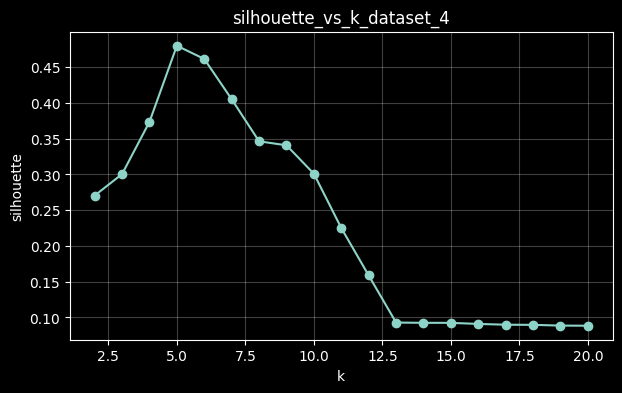

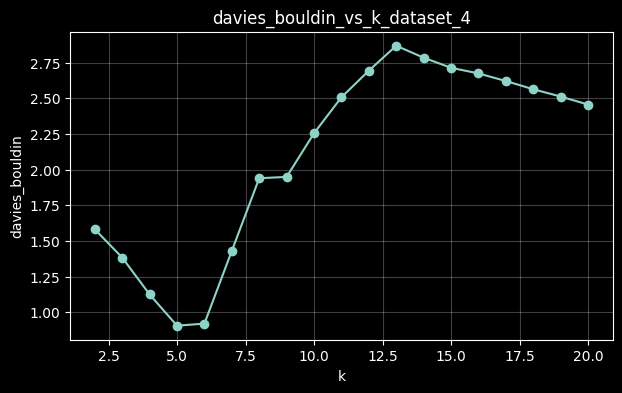

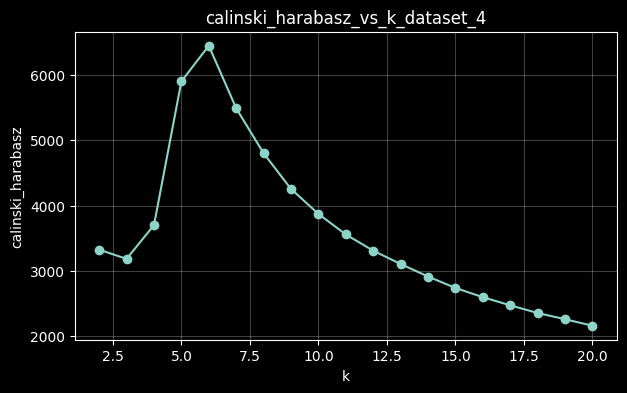

In [21]:
sil_inert_vs_k_grid(kmeans_results4, "silhouette_vs_k_dataset_4", "davies_bouldin_vs_k_dataset_4", "calinski_harabasz_vs_k_dataset_4")

In [22]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

Лучшая kmeans-модель выбирается по наибольшему silhouette

In [23]:
best_kmeans2, best_kmeans2_s = pick_best_by_silhouette(kmeans_results2)
best_kmeans2["params"], round(best_kmeans2_s, 3)

({'k': 2}, 0.307)

In [24]:
best_kmeans3, best_kmeans3_s = pick_best_by_silhouette(kmeans_results3)
best_kmeans3["params"], round(best_kmeans3_s, 3)

({'k': 4}, 0.33)

In [25]:
best_kmeans4, best_kmeans4_s = pick_best_by_silhouette(kmeans_results4)
best_kmeans4["params"], round(best_kmeans4_s, 3)

({'k': 5}, 0.48)

In [26]:
def external_metrics(labels1, labels2):
    return {
        "ARI": float(adjusted_rand_score(labels1, labels2)),
    }

res1 = eval_kmeans_grid(X_feat2, kmeans_ks, random_state=1)
res2 = eval_kmeans_grid(X_feat2, kmeans_ks, random_state=2)
res3 = eval_kmeans_grid(X_feat2, kmeans_ks, random_state=3)
res4 = eval_kmeans_grid(X_feat2, kmeans_ks, random_state=4)
res5 = eval_kmeans_grid(X_feat2, kmeans_ks, random_state=5)

print(external_metrics(res1[0]["labels"], res2[0]["labels"]))
print(external_metrics(res2[0]["labels"], res3[0]["labels"]))
print(external_metrics(res3[0]["labels"], res4[0]["labels"]))
print(external_metrics(res4[0]["labels"], res5[0]["labels"]))
print(external_metrics(res5[0]["labels"], res1[0]["labels"]))



{'ARI': 1.0}
{'ARI': 1.0}
{'ARI': 1.0}
{'ARI': 0.9970018752017166}
{'ARI': 0.9970018752017166}


In [27]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    results = []
    n = len(X_feat)

    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)

            noise_frac = float(np.mean(labels == -1))
            # Метрики по non-noise
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]

            # Перенумеруем метки non-noise, чтобы метрики работали корректнее (не обязательно, но аккуратно)
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)

            metrics = None
            n_clusters = 0
            if len(X_nn) >= 10 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))

            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    return results

Метрики для db_scan считаются на non-noise точках

In [28]:
dbscan2_results = eval_dbscan_grid(X_feat2, dbscan_eps, dbscan_min_samples)

In [29]:
dbscan3_results = eval_dbscan_grid(X_feat3, dbscan_eps, dbscan_min_samples)

In [30]:
dbscan4_results = eval_dbscan_grid(X_feat4, dbscan_eps, dbscan_min_samples)

In [31]:
def dbscan_configs(dbscan_results):
    valid = [r for r in dbscan_results if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
    print("Valid DBSCAN configs:", len(valid))

    # Сортировка по silhouette
    valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
    for r in valid_sorted[:8]:
        print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "dav=", round(r["metrics"]["davies_bouldin"], 3), "cal=", round(r["metrics"]["calinski_harabasz"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

    for r in valid_sorted[:8]:
        if r["noise_frac"] <= 0.15:
            best_dbscan = r
            print("Best dbscan:")
            print(best_dbscan["params"], "sil=", round(best_dbscan["metrics"]["silhouette"], 3), "dav=", round(best_dbscan["metrics"]["davies_bouldin"], 3), "cal=", round(best_dbscan["metrics"]["calinski_harabasz"], 3), "noise=", round(best_dbscan["noise_frac"], 3), "clusters=", best_dbscan["n_clusters"])
            return best_dbscan
    else:
        print("No good dbscan found")
        return







Лучшая DBSCAN модель выбирается по наибольшему silhouette, но при этом доля шума не должна быть слишком большой.

In [32]:
best_dbscan2 = dbscan_configs(dbscan2_results)
best_dbscan3 = dbscan_configs(dbscan3_results)
best_dbscan4 = dbscan_configs(dbscan4_results)

Valid DBSCAN configs: 3
{'eps': 0.5, 'min_samples': 10} sil= 0.251 dav= 0.742 cal= 26.169 noise= 0.064 clusters= 2
{'eps': 0.5, 'min_samples': 5} sil= -0.058 dav= 0.79 cal= 49.822 noise= 0.045 clusters= 14
{'eps': 0.5, 'min_samples': 3} sil= -0.063 dav= 0.821 cal= 40.084 noise= 0.025 clusters= 32
Best dbscan:
{'eps': 0.5, 'min_samples': 10} sil= 0.251 dav= 0.742 cal= 26.169 noise= 0.064 clusters= 2
Valid DBSCAN configs: 2
{'eps': 0.5, 'min_samples': 10} sil= 0.243 dav= 0.649 cal= 11.235 noise= 0.014 clusters= 2
{'eps': 0.5, 'min_samples': 3} sil= 0.078 dav= 0.589 cal= 11.532 noise= 0.006 clusters= 5
Best dbscan:
{'eps': 0.5, 'min_samples': 10} sil= 0.243 dav= 0.649 cal= 11.235 noise= 0.014 clusters= 2
Valid DBSCAN configs: 26
{'eps': 1.5, 'min_samples': 10} sil= 0.501 dav= 1.221 cal= 2841.509 noise= 0.553 clusters= 9
{'eps': 3.0, 'min_samples': 3} sil= 0.48 dav= 0.906 cal= 5901.365 noise= 0.0 clusters= 5
{'eps': 3.0, 'min_samples': 5} sil= 0.48 dav= 0.906 cal= 5901.365 noise= 0.0 clust

In [33]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = safe_cluster_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

In [34]:
agg2_results = eval_agglomerative_grid(X_feat2, agg_ks, agg_linkages)

In [35]:
agg3_results = eval_agglomerative_grid(X_feat3, agg_ks, agg_linkages)

In [36]:
agg4_results = eval_agglomerative_grid(X_feat4, agg_ks, agg_linkages)

In [37]:
def agg_metrics_vs_k_by_link(agg_results, title_sil: str, title_dav: str, title_cal: str):
    plt.figure(figsize=(7, 4))

    for linkage_name in agg_linkages:
        subset = [r for r in agg_results if r["params"]["linkage"] == linkage_name]
        subset = sorted(subset, key=lambda r: r["params"]["k"])
        ks = [r["params"]["k"] for r in subset]
        sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in subset]
        plt.plot(ks, sil, marker="o", label=linkage_name)

    plt.title(title_sil)
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.savefig(f"artifacts/figures/{title_sil}")
    plt.show()


    plt.figure(figsize=(7, 4))

    for linkage_name in agg_linkages:
        subset = [r for r in agg_results if r["params"]["linkage"] == linkage_name]
        subset = sorted(subset, key=lambda r: r["params"]["k"])
        ks = [r["params"]["k"] for r in subset]
        dav = [r["metrics"]["davies_bouldin"] if r["metrics"] else None for r in subset]
        plt.plot(ks, dav, marker="o", label=linkage_name)

    plt.title(title_dav)
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.savefig(f"artifacts/figures/{title_dav}")
    plt.show()


    plt.figure(figsize=(7, 4))

    for linkage_name in agg_linkages:
        subset = [r for r in agg_results if r["params"]["linkage"] == linkage_name]
        subset = sorted(subset, key=lambda r: r["params"]["k"])
        ks = [r["params"]["k"] for r in subset]
        cal = [r["metrics"]["calinski_harabasz"] if r["metrics"] else None for r in subset]
        plt.plot(ks, cal, marker="o", label=linkage_name)

    plt.title(title_cal)
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.savefig(f"artifacts/figures/{title_cal}")
    plt.show()


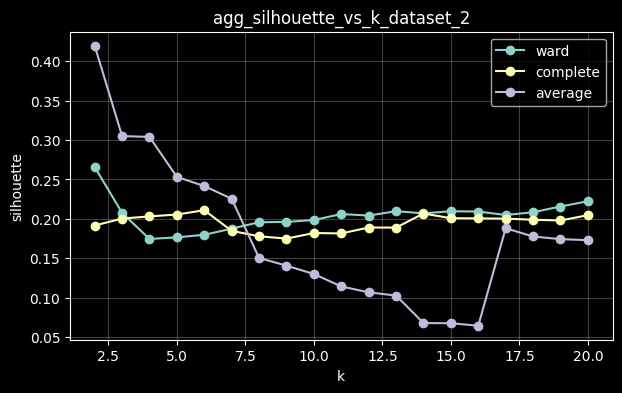

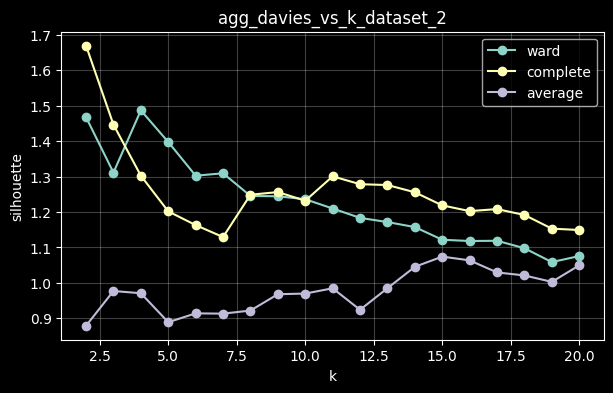

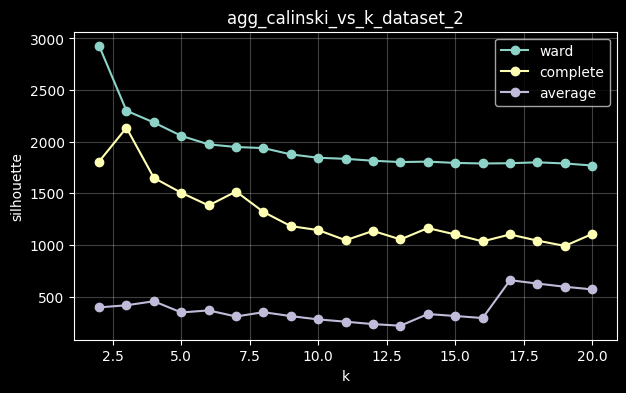

In [38]:
agg_metrics_vs_k_by_link(agg2_results, "agg_silhouette_vs_k_dataset_2", "agg_davies_vs_k_dataset_2", "agg_calinski_vs_k_dataset_2")

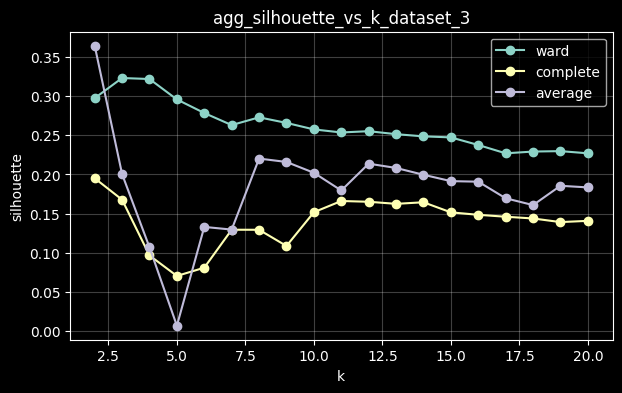

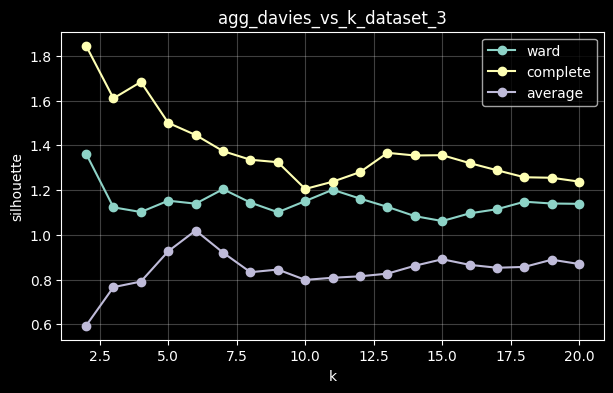

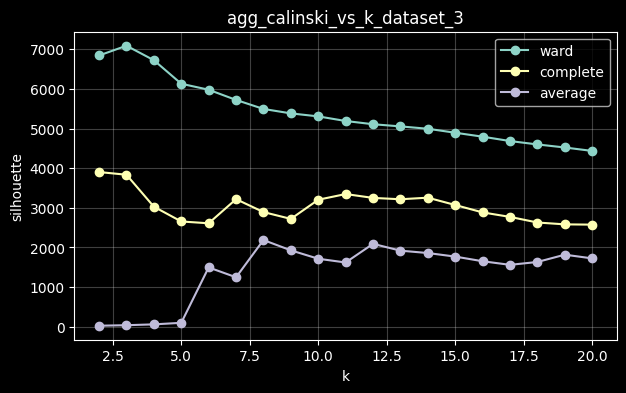

In [39]:
agg_metrics_vs_k_by_link(agg3_results, "agg_silhouette_vs_k_dataset_3", "agg_davies_vs_k_dataset_3", "agg_calinski_vs_k_dataset_3")

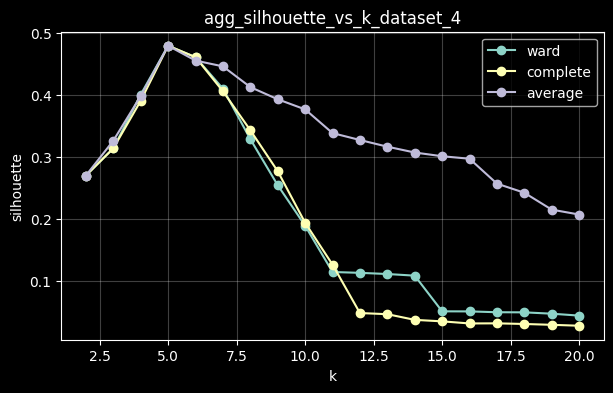

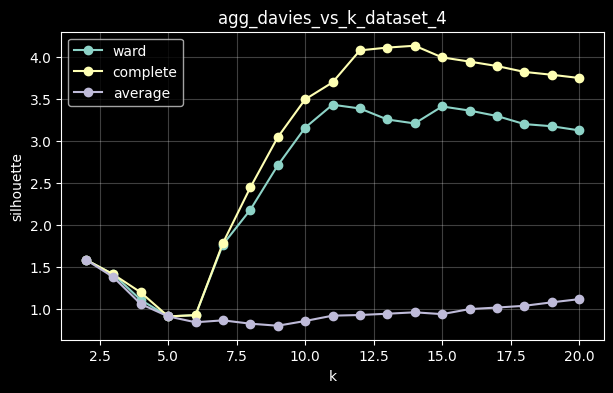

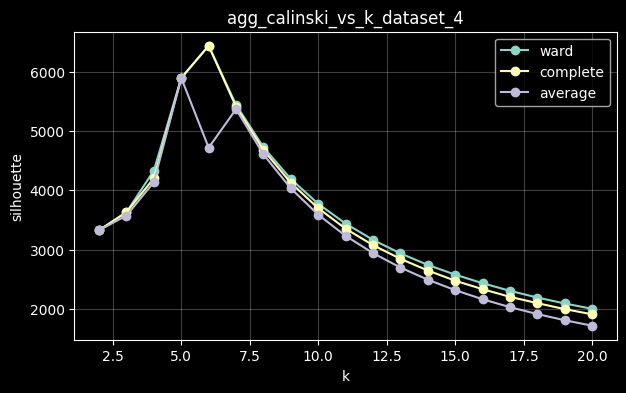

In [40]:
agg_metrics_vs_k_by_link(agg4_results, "agg_silhouette_vs_k_dataset_4", "agg_davies_vs_k_dataset_4", "agg_calinski_vs_k_dataset_4")

Лучшая AgglomerativeClustering модель выбирается по наибольшему silhouette

In [41]:
best_agg2, best_agg2_s = pick_best_by_silhouette(agg2_results)
best_agg2["params"], round(best_agg2_s, 3)

({'k': 2, 'linkage': 'average'}, 0.42)

In [42]:
best_agg3, best_agg3_s = pick_best_by_silhouette(agg3_results)
best_agg3["params"], round(best_agg3_s, 3)

({'k': 2, 'linkage': 'average'}, 0.364)

In [43]:
best_agg4, best_agg4_s = pick_best_by_silhouette(agg4_results)
best_agg4["params"], round(best_agg4_s, 3)

({'k': 5, 'linkage': 'ward'}, 0.48)

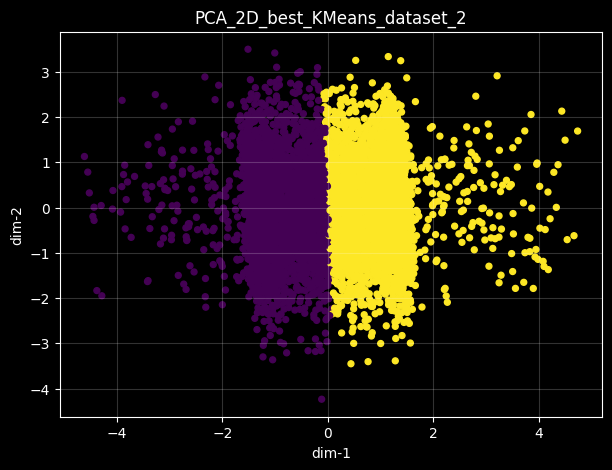

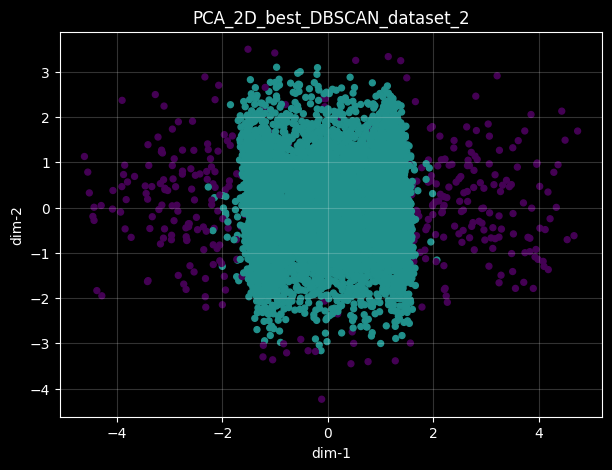

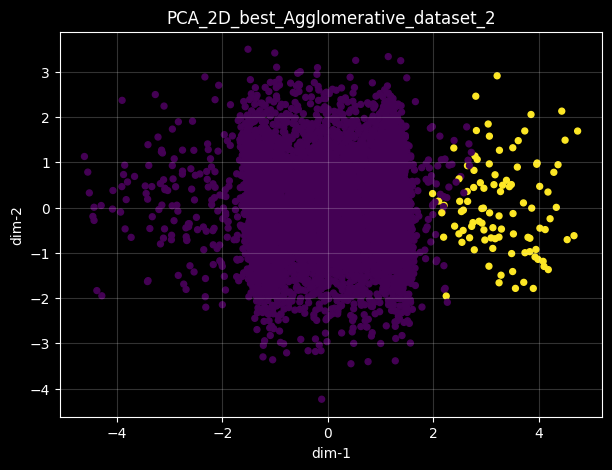

In [44]:
X2_plot2d = pca_2d_for_plot(X2_scaled, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X2_plot2d, best_kmeans2["labels"],
    title="PCA_2D_best_KMeans_dataset_2"
)

# DBSCAN best (if exists)
if best_dbscan2 is not None:
    plot_2d_embedding(
        X2_plot2d, best_dbscan2["labels"],
        title="PCA_2D_best_DBSCAN_dataset_2"
    )

# Agglomerative best
plot_2d_embedding(
    X2_plot2d, best_agg2["labels"],
    title="PCA_2D_best_Agglomerative_dataset_2"
)

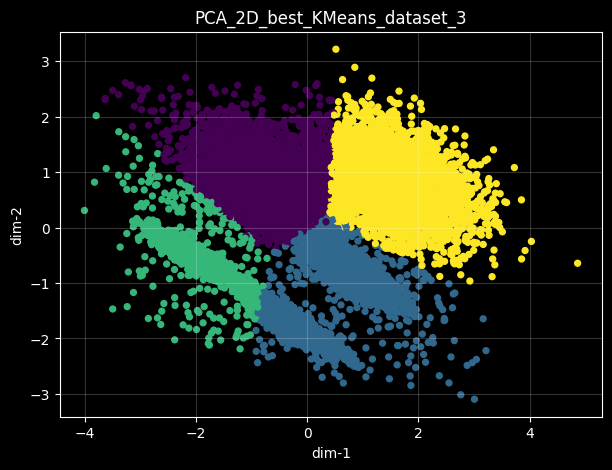

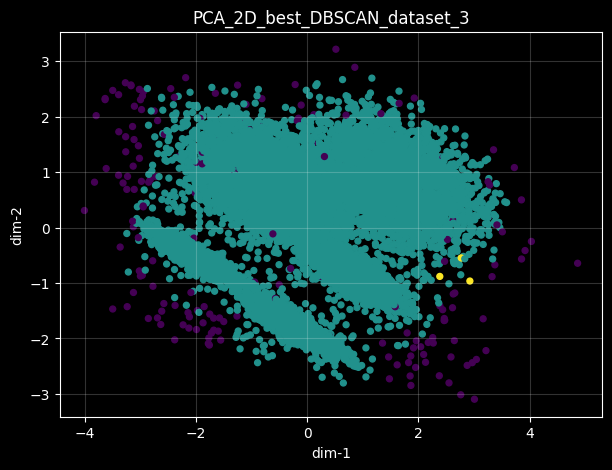

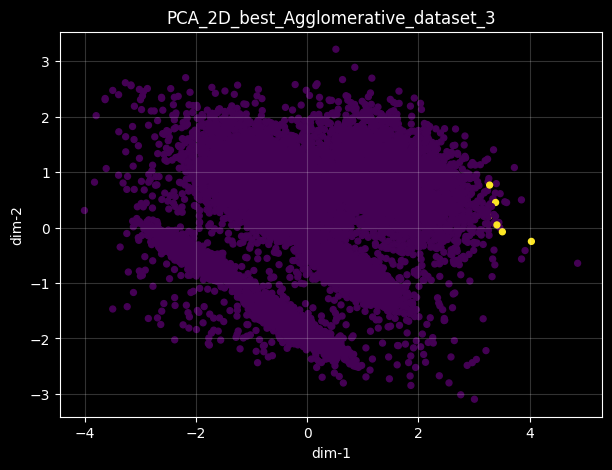

In [45]:
X3_plot2d = pca_2d_for_plot(X3_scaled, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X3_plot2d, best_kmeans3["labels"],
    title="PCA_2D_best_KMeans_dataset_3"
)

# DBSCAN best (if exists)
if best_dbscan3 is not None:
    plot_2d_embedding(
        X3_plot2d, best_dbscan3["labels"],
        title="PCA_2D_best_DBSCAN_dataset_3"
    )

# Agglomerative best
plot_2d_embedding(
    X3_plot2d, best_agg3["labels"],
    title="PCA_2D_best_Agglomerative_dataset_3"
)

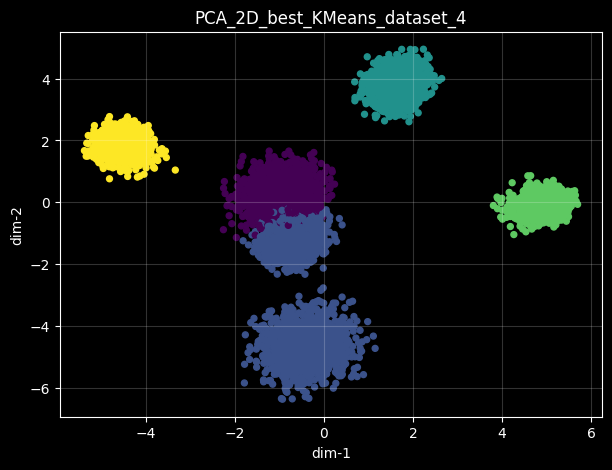

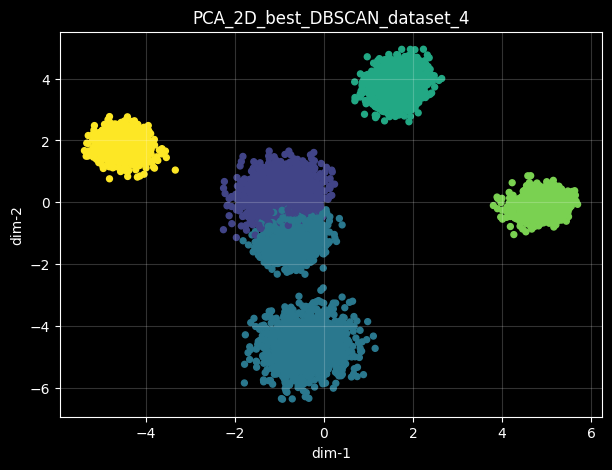

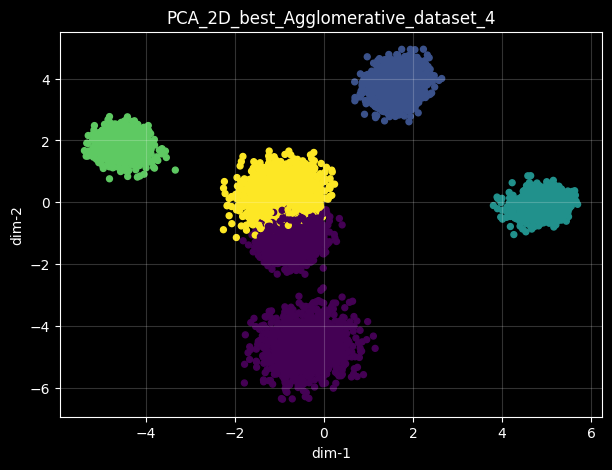

In [46]:
X4_plot2d = pca_2d_for_plot(X4_scaled, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X4_plot2d, best_kmeans4["labels"],
    title="PCA_2D_best_KMeans_dataset_4"
)

# DBSCAN best (if exists)
if best_dbscan4 is not None:
    plot_2d_embedding(
        X4_plot2d, best_dbscan4["labels"],
        title="PCA_2D_best_DBSCAN_dataset_4"
    )

# Agglomerative best
plot_2d_embedding(
    X4_plot2d, best_agg4["labels"],
    title="PCA_2D_best_Agglomerative_dataset_4"
)

In [47]:
# print(best_kmeans2)
# print()
# print(best_dbscan2)
# print()
# print(best_agg2)

# print(type(best_kmeans2))
# print(type(best_dbscan2))
# print(type(best_agg2))

results2 = []
results2.append(best_kmeans2)
results2.append(best_dbscan2)
results2.append(best_agg2)

df_data = []
for r in results2:
    row = {
        'algo': r['algo'],
        'silhouette': round(r['metrics']['silhouette'], 2),
        'davies_bouldin': round(r['metrics']['davies_bouldin'], 2),
        'calinski_harabasz': round(r['metrics']['calinski_harabasz'], 2),
        'noise_frac': round(r['noise_frac'], 4),
    }
    df_data.append(row)

results2_df = pd.DataFrame(df_data)

results2_df = results2_df.sort_values(
    by=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    ascending=[False, True, False]
)
display(results2_df)

print(results2_df.iloc[0]["algo"])

,algo,silhouette,davies_bouldin,calinski_harabasz,noise_frac
2,agglomerative,0.42,0.88,395.48,0.0000
0,kmeans,0.31,1.32,3573.39,0.0000
1,dbscan,0.25,0.74,26.17,0.0636


agglomerative


Лучший алгоритм выбирается по трем сортировкам с убыванием приоритета: по убыванию silhouette, возрастанию davies_bouldin_score, убыванию calinski_harabasz_score.

В датасете были протестированы несколько алгоритмов кластеризации, после чего лучший выбирался по трём метрикам: максимизация silhouette, минимизация davies_bouldin_score и максимизация calinski_harabasz_score. Основные сложности были связаны с наличием выбросов, различной плотностью кластеров и искажением расстояний из-за шумового признака. AgglomerativeClustering оказался лучшим, так как иерархический подход делает его более устойчивым к форме кластеров и менее чувствительным к шуму.

In [48]:
results3 = []
results3.append(best_kmeans3)
results3.append(best_dbscan3)
results3.append(best_agg3)

df_data = []
for r in results3:
    row = {
        'algo': r['algo'],
        'silhouette': round(r['metrics']['silhouette'], 2),
        'davies_bouldin': round(r['metrics']['davies_bouldin'], 2),
        'calinski_harabasz': round(r['metrics']['calinski_harabasz'], 2),
        'noise_frac': round(r['noise_frac'], 4)
    }
    df_data.append(row)

results3_df = pd.DataFrame(df_data)

results3_df = results3_df.sort_values(
    by=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    ascending=[False, True, False]
)
display(results3_df)

print(results3_df.iloc[0]["algo"])

,algo,silhouette,davies_bouldin,calinski_harabasz,noise_frac
2,agglomerative,0.36,0.59,25.20,0.0000
0,kmeans,0.33,1.11,6941.48,0.0000
1,dbscan,0.24,0.65,11.24,0.0135


agglomerative


Лучший алгоритм выбирается по трем сортировкам с убыванием приоритета: по убыванию silhouette, возрастанию davies_bouldin_score, убыванию calinski_harabasz_score.

В датасете были протестированы несколько алгоритмов кластеризации, после чего лучший выбирался по трём метрикам: максимизация silhouette, минимизация davies_bouldin_score и максимизация calinski_harabasz_score. Основные сложности были связаны с неоднородной плотностью кластеров и наличием шумовых точек, что особенно осложняло выбор параметра eps для DBSCAN. AgglomerativeClustering оказался лучшим, так как иерархический подход не требует задания глобального радиуса плотности и лучше адаптируется к кластерам разной плотности.

In [49]:
results4 = []
results4.append(best_kmeans4)
results4.append(best_dbscan4)
results4.append(best_agg4)

# print(best_kmeans4)
# print(best_agg4)
df_data = []
for r in results4:
    row = {
        'algo': r['algo'],
        'silhouette': round(r['metrics']['silhouette'], 2),
        'davies_bouldin': round(r['metrics']['davies_bouldin'], 2),
        'calinski_harabasz': round(r['metrics']['calinski_harabasz'], 2),
        'noise_frac': round(r['noise_frac'], 4)
    }
    df_data.append(row)

results4_df = pd.DataFrame(df_data)

results4_df = results4_df.sort_values(
    by=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    ascending=[False, True, False]
)
display(results4_df)

print(results4_df.iloc[0]["algo"])

,algo,silhouette,davies_bouldin,calinski_harabasz,noise_frac
1,dbscan,0.48,0.91,5901.36,0.0001
0,kmeans,0.48,0.91,5899.35,0.0000
2,agglomerative,0.48,0.91,5899.35,0.0000


dbscan


Лучший алгоритм выбирается по трем сортировкам с убыванием приоритета: по убыванию silhouette, возрастанию davies_bouldin_score, убыванию calinski_harabasz_score.

В датасете были протестированы несколько алгоритмов кластеризации, после чего лучший выбирался по трём метрикам: максимизация silhouette, минимизация davies_bouldin_score и максимизация calinski_harabasz_score. Основные сложности были связаны с необходимостью корректного кодирования категориальных признаков, обработкой пропусков и разной шкалой признаков в многомерном пространстве. DBSCAN оказался лучшим, так как способен отделять шумовые точки и не требует заранее задавать число кластеров.

In [50]:
import json

df_data2 = []
df_data3 = []
df_data4 = []

for r in results2:
    row = {
        'algo': r['algo'],
        'silhouette': round(r['metrics']['silhouette'], 2),
        'davies_bouldin': round(r['metrics']['davies_bouldin'], 2),
        'calinski_harabasz': round(r['metrics']['calinski_harabasz'], 2),
    }

    if r['algo'] == 'dbscan':
        row['noise_frac'] = round(r['noise_frac'], 2)

    df_data2.append(row)

for r in results3:
    row = {
        'algo': r['algo'],
        'silhouette': round(r['metrics']['silhouette'], 2),
        'davies_bouldin': round(r['metrics']['davies_bouldin'], 2),
        'calinski_harabasz': round(r['metrics']['calinski_harabasz'], 2),
    }

    if r['algo'] == 'dbscan':
        row['noise_frac'] = round(r['noise_frac'], 2)

    df_data3.append(row)

for r in results4:
    row = {
        'algo': r['algo'],
        'silhouette': round(r['metrics']['silhouette'], 2),
        'davies_bouldin': round(r['metrics']['davies_bouldin'], 2),
        'calinski_harabasz': round(r['metrics']['calinski_harabasz'], 2),
    }

    if r['algo'] == 'dbscan':
        row['noise_frac'] = round(r['noise_frac'], 2)

    df_data4.append(row)

metrics_summary = [
    {
        "dataset":  "S07-hw-dataset-02.csv",
        "models": df_data2
    },
    {
        "dataset":  "S07-hw-dataset-03.csv",
        "models": df_data3
    },
    {
        "dataset":  "S07-hw-dataset-04.csv",
        "models": df_data4
    }
]

with open("artifacts/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=4)


In [51]:
configs2 = []
configs3 = []
configs4 = []

for r in results2:
    row = {
        'algo': r['algo'],
        'params': r['params'],
    }
    if r['algo'] == 'kmeans':
        row['criterion'] = 'biggest silhouette'
    if r['algo'] == 'dbscan':
        row['criterion'] = 'biggest silhouette, noise_frac <= 0.15'
    if r['algo'] == 'agglomerative':
        row['criterion'] = 'biggest silhouette'
    configs2.append(row)

for r in results3:
    row = {
        'algo': r['algo'],
        'params': r['params'],
    }
    if r['algo'] == 'kmeans':
        row['criterion'] = 'biggest silhouette'
    if r['algo'] == 'dbscan':
        row['criterion'] = 'biggest silhouette, noise_frac <= 0.15'
    if r['algo'] == 'agglomerative':
        row['criterion'] = 'biggest silhouette'
    configs3.append(row)

for r in results4:
    row = {
        'algo': r['algo'],
        'params': r['params'],
    }
    if r['algo'] == 'kmeans':
        row['criterion'] = 'biggest silhouette'
    if r['algo'] == 'dbscan':
        row['criterion'] = 'biggest silhouette, noise_frac <= 0.15'
    if r['algo'] == 'agglomerative':
        row['criterion'] = 'biggest silhouette'
    configs4.append(row)


best_configs = [
    {
        "dataset":  "S07-hw-dataset-02.csv",
        "models": configs2
    },
    {
        "dataset":  "S07-hw-dataset-03.csv",
        "models": configs3
    },
    {
        "dataset":  "S07-hw-dataset-04.csv",
        "models": configs4
    }
]

with open("artifacts/best_configs.json", "w") as f:
    json.dump(best_configs, f, indent=4)


In [52]:
# print(best_agg2)
# print(best_agg3)
# print(best_dbscan4)

clusters2 = summarize_labels(best_agg2["labels"])
for cluster_id in clusters2:
    mask = best_agg2["labels"] == cluster_id
    cluster_data = X_feat2[mask]

    print(f"Кластер {cluster_id}:  {mask.sum()} точек")
    print(f"Средние значения: {cluster_data.mean(axis=0)}")
    print(f"Медианы: {np.median(cluster_data, axis=0)}")
    print()

print('\n\n')

clusters3 = summarize_labels(best_agg3["labels"])
for cluster_id in clusters3:
    mask = best_agg3["labels"] == cluster_id
    cluster_data = X_feat3[mask]

    print(f"Кластер {cluster_id}:  {mask.sum()} точек")
    print(f"Средние значения: {cluster_data.mean(axis=0)}")
    print(f"Медианы: {np.median(cluster_data, axis=0)}")
    print()

print('\n\n')

clusters4 = summarize_labels(best_dbscan4["labels"])
for cluster_id in clusters4:
    mask = best_dbscan4["labels"] == cluster_id
    cluster_data = X_feat4[mask]

    print(f"Кластер {cluster_id}:  {mask.sum()} точек")
    print(f"Средние значения: {cluster_data.mean(axis=0)}")
    print(f"Медианы: {np.median(cluster_data, axis=0)}")
    print()


Кластер 0:  7902 точек
Средние значения: [-0.04087285 -0.00036997 -0.00907348]
Медианы: [-0.02925428 -0.00093941  0.00493462]

Кластер 1:  98 точек
Средние значения: [3.29568615 0.02983136 0.73161909]
Медианы: [ 3.2446224  -0.07315825  0.64199071]




Кластер 0:  14994 точек
Средние значения: [-1.39431618e-03 -7.71542025e-05  8.07382146e-04]
Медианы: [ 0.00533777  0.10361552 -0.00798633]

Кластер 1:  6 точек
Средние значения: [ 3.48439614  0.19280835 -2.01764798]
Медианы: [ 3.40212603  0.12926661 -1.96357368]




Кластер -1:  1 точек
Средние значения: [-0.74412406 -0.52413577  1.13404751 -1.12613657 -2.58403458  2.2002169
 -2.36578565  3.76147973 -0.22820197 -1.52536725  1.3238507  -0.4182421 ]
Медианы: [-0.74412406 -0.52413577  1.13404751 -1.12613657 -2.58403458  2.2002169
 -2.36578565  3.76147973 -0.22820197 -1.52536725  1.3238507  -0.4182421 ]

Кластер 0:  1667 точек
Средние значения: [-0.95608559  0.21312589 -4.33166396 -1.11160024  0.3289941   0.02490656
  0.01657612 -0.05226051  

In [53]:
labels2 = []
labels3 = []
labels4 = []

for i in range(len(best_agg2["labels"])):
    labels2.append([sample_id2[i], best_agg2["labels"][i]])

for i in range(len(best_agg3["labels"])):
    labels3.append([sample_id3[i], best_agg3["labels"][i]])

for i in range(len(best_dbscan4["labels"])):
    if best_dbscan4["labels"][i] == None:
        best_dbscan4["labels"][i] = -1
    labels4.append([sample_id4[i], best_dbscan4["labels"][i]])

pd.DataFrame(labels2, columns=['sample_id', 'cluster_label']).to_csv("artifacts/labels/labels_hw07_ds2.csv", index=False)
pd.DataFrame(labels3, columns=['sample_id', 'cluster_label']).to_csv("artifacts/labels/labels_hw07_ds3.csv", index=False)
pd.DataFrame(labels4, columns=['sample_id', 'cluster_label']).to_csv("artifacts/labels/labels_hw07_ds4.csv", index=False)